In [1]:
# -------------------------------------------------------------
# 셀 1: 라이브러리 임포트 및 함수 정의
# -------------------------------------------------------------
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pickle
import sys
from torch_geometric.explain import GNNExplainer
from torch_geometric.data import Data, Batch

# 🚨 주의: models/a3tgcn.py, utils/device_set.py 파일이 
# 런타임 환경의 PATH에 있어야 합니다.
try:
    # 기존 파일들 임포트 (모델 클래스 및 유틸리티)
    # A3TGCNCat2가 정의된 파일을 모듈로 임포트합니다.
    from models.a3tgcn import A3TGCNCat2 
    from utils.device_set import device_set
except ImportError:
    print("❌ 모델 및 유틸리티 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    # 임시적으로 더미 클래스로 대체하거나, sys.path를 수정해야 할 수 있습니다.

# -------------------------------------------------------------
# 셀 1: 라이브러리 임포트 및 함수 정의 (수정됨)
# -------------------------------------------------------------
# ... (위쪽 임포트 부분은 동일) ...

class A3TGCNHybridExplainer:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.model.eval()
        
    def get_temporal_importance(self, batch_list, edge_index):
        # ... (이전과 동일) ...
        with torch.no_grad():
            _ = self.model(batch_list, edge_index)
        last_layer = self.model.a3tgcn_layers[-1]
        
        if hasattr(last_layer, '_attention') and last_layer._attention is not None:
            attn_weights = last_layer._attention
        elif hasattr(last_layer, 'attention_weights') and last_layer.attention_weights is not None:
            attn_weights = last_layer.attention_weights
        else:
            T = len(batch_list)
            return torch.ones((batch_list[0].batch_size, T)).to(self.device) / T

        if attn_weights.dim() == 3: 
            attn_weights = attn_weights.mean(dim=1)
        return attn_weights.squeeze() 

    def explain_spatial_step(self, x_snapshot, edge_index, node_idx=0):
        """특정 타임스텝의 스냅샷에 대해 GNNExplainer(New API)를 실행합니다."""
        from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
        
        # 🚨 [수정 1] 설명 대상을 '마지막 레이어(-1)'에서 '첫 번째 레이어(0)'로 변경
        # 이유: 우리가 넣을 x_snapshot은 초기 입력 데이터이기 때문입니다.
        target_gcn = self.model.a3tgcn_layers[0]._base_tgcn.conv_h
        
        explainer = Explainer(
            model=target_gcn, 
            algorithm=GNNExplainer(epochs=100),
            explanation_type='model',
            node_mask_type='attributes',
            edge_mask_type='object',
            model_config=dict(
                mode='multiclass_classification', 
                task_level='node',
                return_type='raw',
            ),
        )
        
        # 설명 생성
        explanation = explainer(
            x=x_snapshot, 
            edge_index=edge_index, 
            index=node_idx
        )
        
        return explanation.edge_mask, explanation.node_mask

# ... (visualize_explanation 함수 등 나머지는 동일) ...

# -------------------------------------------------------------
# 함수 3: 시각화 함수 (visualize_explanation)
# -------------------------------------------------------------
def visualize_explanation(temporal_weights, edge_mask, edge_index, time_idx, node_idx):
    """결과를 시각화합니다."""
    # (시각화 코드 - 원본과 동일)
    plt.figure(figsize=(12, 5))
    
    # 1. 시간 중요도 (Attention)
    plt.subplot(1, 2, 1)
    t_weights = temporal_weights.cpu().numpy()
    plt.plot(t_weights, marker='o', linestyle='-', color='b')
    plt.axvline(x=time_idx, color='r', linestyle='--', label=f'Selected Time t={time_idx}')
    plt.title(f'Temporal Attention (Node {node_idx} context)')
    plt.xlabel('Time Step (History)')
    plt.ylabel('Attention Weight')
    plt.legend()
    
    # 2. 공간 중요도 (Edge Weights distribution)
    plt.subplot(1, 2, 2)
    e_weights = edge_mask.cpu().detach().numpy()
    sns.histplot(e_weights, bins=20)
    plt.title(f'Edge Importance Distribution at t={time_idx}')
    plt.xlabel('Importance Score')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    print(f"Top 5 Important Edges Indices at t={time_idx}:")
    top_indices = e_weights.argsort()[-5:][::-1]
    print(edge_index[:, top_indices])

/opt/miniconda3/envs/pyg_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_trained_model(checkpoint_path, data_path, device):
    """
    저장된 체크포인트와 데이터 파일을 사용하여 모델을 복원하고 데이터셋을 반환합니다.
    """
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"데이터 파일이 없습니다: {data_path}")

    print(f"Loading data info from {data_path}...")
    with open(data_path, 'rb') as f:
        # 🚨 [변경됨] 저장 코드: pickle.dump(result, f) -> result는 리스트
        # 0: train, 1: val, 2: test, 3: col_info
        pickle_data = pickle.load(f)
    
    # 3번 인덱스가 col_info (admission_cols, col_dims)
    col_info = pickle_data[3]
    col_list, col_dim = col_info

    # 모델 구조 초기화
    model = A3TGCNCat2(
        col_dims=col_dim, 
        col_list=col_list, 
        num_layers=2, 
        hidden_channel=64, 
        out_channel=2
    )
    model.to(device)

    # 가중치 로드
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"체크포인트 파일이 없습니다: {checkpoint_path}")

    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    try:
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        print("✅ 모델 가중치 로드 성공!")
    except RuntimeError as e:
        print(f"❌ 로드 실패: {e}")
        raise e

    model.eval()
    
    # 🚨 [중요] 전체 리스트를 반환하여 Cell 2에서 unpacking 할 수 있게 함
    return model, pickle_data

In [3]:
# -------------------------------------------------------------
# 셀 2: 환경 설정, 데이터 로드, 모델 준비
# -------------------------------------------------------------
import os
import torch
import pickle

# 1. 디바이스 설정
DEVICE = device_set()

# 2. 경로 설정 (현재 작업 경로 기준)
# 🚨 주의: 파일 경로가 정확한지 확인해 주세요.
CUR_DIR = os.getcwd() 
DATA_PATH = os.path.join(CUR_DIR, 'data', 'temporal_graph_data_mi.pickle')
# 체크포인트 파일명은 실제 존재하는 파일명으로 변경해야 합니다.
CKPT_PATH = os.path.join(CUR_DIR, 'checkpoints', 'a3tgcn', 'best_model_epoch_4_loss_0.9801.pth') 

print(f"📂 Data Path: {DATA_PATH}")
print(f"📂 Model Path: {CKPT_PATH}")

if os.path.exists(DATA_PATH) and os.path.exists(CKPT_PATH):
    try:
        # load_trained_model은 (model, pickle_data_list)를 반환
        model, pickle_data = load_trained_model(CKPT_PATH, DATA_PATH, DEVICE)
        
        # 🚨 [수정] 리스트 인덱싱으로 데이터 분리
        # pickle_data 구조: [train, val, test, col_info]
        train_dataset = pickle_data[0]
        val_dataset   = pickle_data[1]
        test_dataset  = pickle_data[2]
        col_info      = pickle_data[3]
        
        print(f"✅ 데이터 로드 완료! Test Dataset 개수: {len(test_dataset)}")
        
        # 5. 엣지 인덱스 추출
        # test_dataset[0]은 Signal 객체, list로 변환 후 첫 스냅샷의 edge_index 가져오기
        first_signal_list = list(test_dataset[0])
        template_edge_index = first_signal_list[0].edge_index.to(DEVICE)
        
        # 6. Explainer 초기화
        explainer = A3TGCNHybridExplainer(model, DEVICE)
        print("✅ Explainer 초기화 완료!")
        
        print("\n🎉 준비가 완료되었습니다. 이제 다음 셀을 실행하세요.")
        
    except Exception as e:
        print(f"\n❌ 로드 중 오류 발생: {e}")

Using device: mps
📂 Data Path: /Users/jeong-yunseong/Documents/programming/Phase_2/data/temporal_graph_data_mi.pickle
📂 Model Path: /Users/jeong-yunseong/Documents/programming/Phase_2/checkpoints/a3tgcn/best_model_epoch_4_loss_0.9801.pth
Loading data info from /Users/jeong-yunseong/Documents/programming/Phase_2/data/temporal_graph_data_mi.pickle...
Using device: mps
Using device: mps
Loading checkpoint from /Users/jeong-yunseong/Documents/programming/Phase_2/checkpoints/a3tgcn/best_model_epoch_4_loss_0.9801.pth...
✅ 모델 가중치 로드 성공!
✅ 데이터 로드 완료! Test Dataset 개수: 13071
✅ Explainer 초기화 완료!

🎉 준비가 완료되었습니다. 이제 다음 셀을 실행하세요.



✅ 모델 로드 및 Explainer 준비 완료.
가장 중요한 타임스텝(Lookback): 0
모델이 기대하는 입력 차원(Features): 1500
Final Input Shape for GNN: torch.Size([16, 1500])
GNNExplainer 실행: Time=0, Node=0


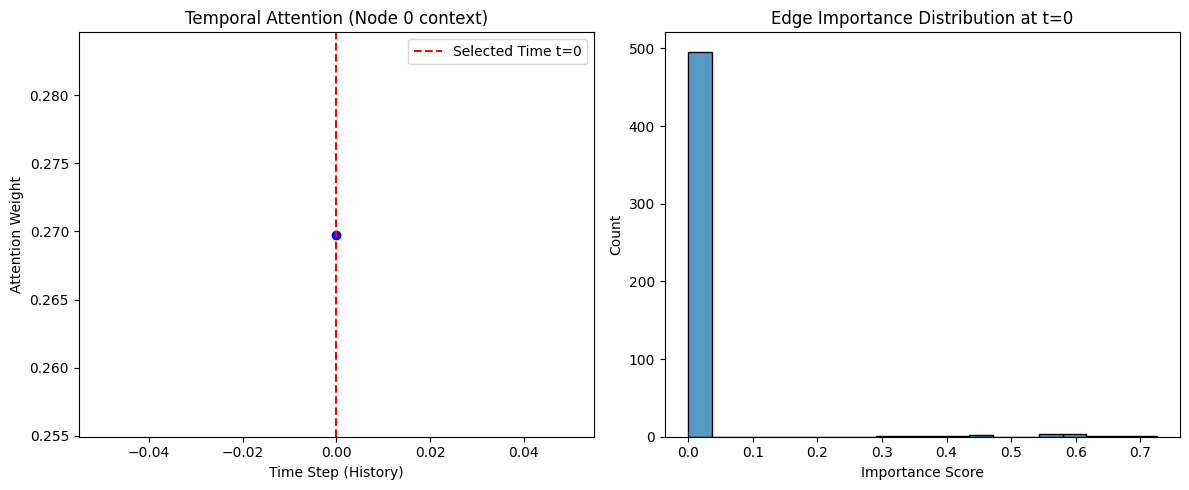

Top 5 Important Edges Indices at t=0:
[[ 3  2 13  6 11]
 [ 0  0  0  0  0]]
=== Node/Edge Importance (Descending Order) for Target Node 0 ===
Total Edges Explained: 511
------------------------------------------------------------
    Source Node  Target Node  Importance
0             3            0    0.725188
1             2            0    0.664503
2            13            0    0.639934
3             6            0    0.601275
4            11            0    0.601130
5            14            0    0.596829
6             1            0    0.575315
7            10            0    0.554886
8             7            0    0.549820
9             8            0    0.438969
10            9            0    0.436050
11           12            0    0.404677
12           15            0    0.364674
13            4            0    0.341927
14            5            0    0.325999
15           48            0    0.000000
16           49            3    0.000000
17           50            2    0

In [4]:
# -------------------------------------------------------------
# 셀 3: 설명 실행 및 시각화 (Negative Stride 에러 수정판)
# -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # numpy 임포트 확인

# 🚨 [수정됨] 시각화 함수 재정의 (.copy() 추가)
def visualize_explanation(temporal_weights, edge_mask, edge_index, time_idx, node_idx):
    """결과를 시각화합니다."""
    plt.figure(figsize=(12, 5))
    
    # 1. 시간 중요도 (Attention)
    plt.subplot(1, 2, 1)
    t_weights = temporal_weights.detach().cpu().numpy()
    plt.plot(t_weights, marker='o', linestyle='-', color='b')
    plt.axvline(x=time_idx, color='r', linestyle='--', label=f'Selected Time t={time_idx}')
    plt.title(f'Temporal Attention (Node {node_idx} context)')
    plt.xlabel('Time Step (History)')
    plt.ylabel('Attention Weight')
    plt.legend()
    
    # 2. 공간 중요도 (Edge Weights distribution)
    plt.subplot(1, 2, 2)
    e_weights = edge_mask.detach().cpu().numpy()
    sns.histplot(e_weights, bins=20)
    plt.title(f'Edge Importance Distribution at t={time_idx}')
    plt.xlabel('Importance Score')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Top 5 Important Edges Indices at t={time_idx}:")
    
    # 🚨 [핵심 수정] [::-1] 뒤에 .copy()를 붙여 음수 스트라이드 제거
    top_indices = e_weights.argsort()[-5:][::-1].copy()
    
    # edge_index는 텐서이므로 인덱싱 후 cpu로 이동
    print(edge_index[:, top_indices].cpu().numpy())


# --- 실행 로직 ---

# 1. 설명할 샘플 선택
target_sample_idx = 0
target_node_idx = 0
signal = test_dataset[target_sample_idx]
batch_list = [b.to(DEVICE) for b in signal]

print("\n✅ 모델 로드 및 Explainer 준비 완료.")

# --- Step 1: 시간적 중요도 (Attention) 추출 ---
temporal_weights = explainer.get_temporal_importance(batch_list, template_edge_index)

if temporal_weights.dim() > 1:
    sample_temporal_weights = temporal_weights[0] 
else:
    sample_temporal_weights = temporal_weights

# 가장 중요한 타임스텝 찾기
most_important_time_idx = torch.argmax(sample_temporal_weights).item()
print(f"가장 중요한 타임스텝(Lookback): {most_important_time_idx}")

# --- Step 2: 공간적 중요도 (GNNExplainer) 추출을 위한 특징 준비 ---
with torch.no_grad():
    target_batch = batch_list[most_important_time_idx]
    
    # 1. 초기 임베딩 추출
    x_emb_raw = model.entitiy_embedding(target_batch) 
    
    # 2. 차원 수정 (Reshape)
    target_layer = model.a3tgcn_layers[0]._base_tgcn.conv_h
    expected_in_channels = target_layer.in_channels 
    print(f"모델이 기대하는 입력 차원(Features): {expected_in_channels}")
    
    x_emb = x_emb_raw.reshape(-1, expected_in_channels)
    print(f"Final Input Shape for GNN: {x_emb.shape}")

# --- Step 3: GNNExplainer 실행 ---
print(f"GNNExplainer 실행: Time={most_important_time_idx}, Node={target_node_idx}")

current_edge_index = target_batch.edge_index

edge_mask, node_mask = explainer.explain_spatial_step(
    x_emb, 
    current_edge_index, 
    node_idx=target_node_idx
)

# --- Step 4: 시각화 ---
visualize_explanation(
    sample_temporal_weights, 
    edge_mask, 
    current_edge_index, 
    most_important_time_idx, 
    target_node_idx
)
import pandas as pd

# 1. 텐서를 NumPy 배열로 변환 (이미 detach되어 있을 수 있으나 안전하게 처리)
# edge_mask: 각 엣지의 중요도 점수
# current_edge_index: [2, num_edges] 형태의 엣지 연결 정보 (0: Source, 1: Target)
e_weights_np = edge_mask.detach().cpu().numpy()
edge_index_np = current_edge_index.detach().cpu().numpy()

# 2. 데이터프레임 생성
# GNN에서 'Source Node'는 정보를 주는 노드(이웃), 'Target Node'는 정보를 받는 노드입니다.
df_importance = pd.DataFrame({
    'Source Node': edge_index_np[0],  # 이웃 노드 (정보 제공)
    'Target Node': edge_index_np[1],  # 중심 노드 (정보 수신)
    'Importance': e_weights_np
})

# 3. 중요도 기준 내림차순 정렬
df_sorted = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. 결과 출력
print(f"=== Node/Edge Importance (Descending Order) for Target Node {target_node_idx} ===")
print(f"Total Edges Explained: {len(df_sorted)}")
print("-" * 60)
print(df_sorted.head(20))  # 상위 20개만 출력
print("-" * 60)

# 5. (선택) 노드별 중요도 합계 (만약 한 노드가 여러 번 연결된 경우)
# Source Node 별로 중요도를 합산하여 '진짜 노드 중요도'를 봅니다.
df_node_agg = df_sorted.groupby('Source Node')['Importance'].sum().reset_index()
df_node_agg_sorted = df_node_agg.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n=== Aggregated Node Importance (Top 10 Source Nodes) ===")
print(df_node_agg_sorted.head(10))

🚀 총 1000개의 샘플에 대해 전역 중요도 분석을 시작합니다...


Analyzing Samples: 100%|██████████| 1000/1000 [12:21<00:00,  1.35it/s]


📊 Global Top 20 Important Edges (Averaged over 1000 samples)
    Source Node  Target Node  Avg_Importance  Count
0            14            0        0.535678   1000
1            13            0        0.530858   1000
2            15            0        0.527470   1000
3            11            0        0.526000   1000
4             9            0        0.522881   1000
5            12            0        0.518646   1000
6             8            0        0.514976   1000
7            10            0        0.505137   1000
8             7            0        0.498869   1000
9             3            0        0.492590   1000
10            5            0        0.490393   1000
11            2            0        0.488447   1000
12            1            0        0.482675   1000
13            4            0        0.481899   1000
14            6            0        0.481810   1000
15           49            4        0.000000   1000
16           49            3        0.000000   1000
17


/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_70740/485780627.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Source Node', y='Avg_Importance', data=node_importance.head(10), palette='viridis')


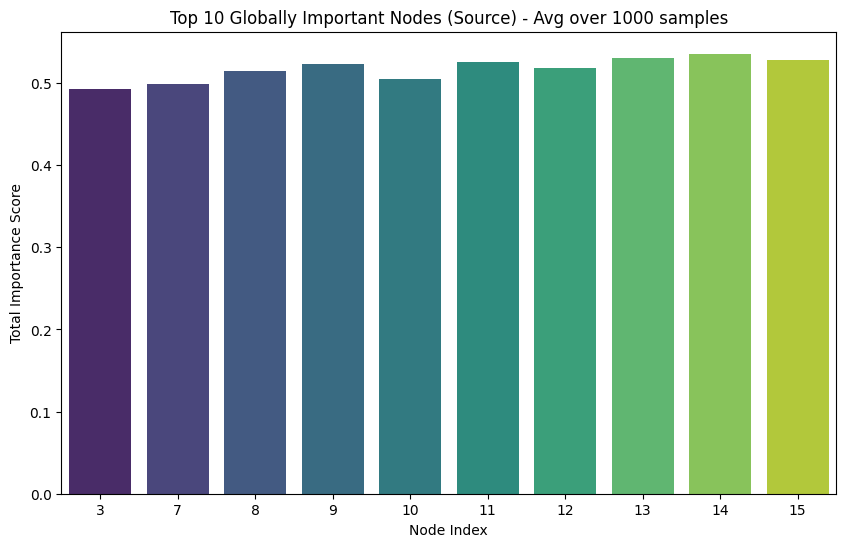

In [5]:
import pandas as pd
from tqdm import tqdm
import numpy as np

def analyze_global_importance(dataset, model, explainer, template_edge_index, num_samples=None):
    """
    데이터셋의 여러 샘플에 대해 중요도를 추출하고 집계합니다.
    
    Args:
        num_samples (int): 분석할 샘플 수. None이면 전체 데이터셋 분석 (오래 걸릴 수 있음).
    """
    
    # 결과를 저장할 리스트 (Source, Target, Importance)
    aggregated_results = []
    
    # 템플릿 엣지 인덱스 (CPU 변환)
    template_edges_np = template_edge_index.cpu().numpy()
    
    # 분석할 샘플 개수 설정
    if num_samples is None:
        samples_to_run = dataset
    else:
        samples_to_run = dataset[:num_samples]
    
    print(f"🚀 총 {len(samples_to_run)}개의 샘플에 대해 전역 중요도 분석을 시작합니다...")
    
    model.eval()
    
    for i, signal in enumerate(tqdm(samples_to_run, desc="Analyzing Samples")):
        try:
            # 1. 데이터 준비
            batch_list = [b.to(DEVICE) for b in signal]
            
            # 2. 시간적 중요도(Attention) 추출 -> 가장 중요한 타임스텝 선정
            temporal_weights = explainer.get_temporal_importance(batch_list, template_edge_index)
            if temporal_weights.dim() > 1:
                temporal_weights = temporal_weights[0]
            
            best_time_idx = torch.argmax(temporal_weights).item()
            
            # 3. 공간적 중요도(GNNExplainer) 준비
            target_batch = batch_list[best_time_idx]
            
            with torch.no_grad():
                x_emb_raw = model.entitiy_embedding(target_batch)
                
                # 차원 보정 (이전 해결책 적용)
                target_layer = model.a3tgcn_layers[0]._base_tgcn.conv_h
                expected_in_channels = target_layer.in_channels
                x_emb = x_emb_raw.reshape(-1, expected_in_channels)
            
            # 4. GNNExplainer 실행
            # (속도를 위해 epochs를 조금 줄여도 되지만, 정확도를 위해 100 유지)
            # 엣지 마스크 추출
            edge_mask, _ = explainer.explain_spatial_step(
                x_emb, 
                target_batch.edge_index,  # 현재 배치의 엣지 사용
                node_idx=0 # 여기서는 Node 0에 대한 중요도를 전역적으로 봅니다. (필요시 루프 가능)
            )
            
            # 5. 결과 수집 (NumPy로 변환)
            mask_np = edge_mask.detach().cpu().numpy()
            
            # 현재 샘플의 중요도를 리스트에 추가
            # (템플릿 엣지 인덱스와 순서가 같다고 가정합니다. A3TGCN은 고정 그래프를 쓰므로 보통 일치합니다.)
            # 만약 dynamic graph라서 엣지가 매번 바뀐다면 target_batch.edge_index를 써야 합니다.
            current_edges = target_batch.edge_index.cpu().numpy()
            
            sample_df = pd.DataFrame({
                'Source Node': current_edges[0],
                'Target Node': current_edges[1],
                'Importance': mask_np,
                'Sample_ID': i
            })
            aggregated_results.append(sample_df)
            
        except Exception as e:
            print(f"⚠️ Error at sample {i}: {e}")
            continue

    # 6. 데이터프레임 합치기
    if not aggregated_results:
        print("❌ 결과가 없습니다.")
        return None

    total_df = pd.concat(aggregated_results, ignore_index=True)
    
    return total_df

# --- 실행 ---

# 🚨 주의: 전체 데이터셋(test_dataset)이 크다면 시간이 매우 오래 걸릴 수 있습니다.
# 테스트를 위해 먼저 20개만 돌려보시는 것을 추천합니다.
# 전체를 다 하려면 num_samples=None 으로 설정하세요.
NUM_SAMPLES = 1000

global_results_df = analyze_global_importance(
    test_dataset, 
    model, 
    explainer, 
    template_edge_index, 
    num_samples=NUM_SAMPLES
)

# --- 결과 집계 및 시각화 ---
if global_results_df is not None:
    # 1. (Source, Target) 별로 중요도 평균(Mean) 계산
    # count는 해당 엣지가 몇 번 등장했는지(몇 개의 샘플에서 중요했는지) 확인용
    summary_df = global_results_df.groupby(['Source Node', 'Target Node']).agg(
        Avg_Importance=('Importance', 'mean'),
        Count=('Importance', 'count')
    ).reset_index()
    
    # 2. 평균 중요도 기준 내림차순 정렬
    summary_df = summary_df.sort_values(by='Avg_Importance', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*50)
    print(f"📊 Global Top 20 Important Edges (Averaged over {NUM_SAMPLES} samples)")
    print("="*50)
    print(summary_df.head(20))
    
    # 3. 노드별 전체 중요도 (Source Node 기준)
    # "어떤 노드가 전반적으로 가장 정보를 많이 주는가?"
    node_importance = summary_df.groupby('Source Node')['Avg_Importance'].sum().reset_index()
    node_importance = node_importance.sort_values(by='Avg_Importance', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*50)
    print("🌟 Global Top 10 Most Influential Nodes (Source Nodes)")
    print("="*50)
    print(node_importance.head(10))
    
    # 4. 시각화 (상위 10개 노드)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Source Node', y='Avg_Importance', data=node_importance.head(10), palette='viridis')
    plt.title(f'Top 10 Globally Important Nodes (Source) - Avg over {NUM_SAMPLES} samples')
    plt.xlabel('Node Index')
    plt.ylabel('Total Importance Score')
    plt.show()

In [6]:
import os
import pickle

# 저장할 경로 및 파일명 설정
SAVE_DIR = os.getcwd()
SAVE_FILENAME = 'global_importance_analysis_results_1000.pickle'
SAVE_PATH = os.path.join(SAVE_DIR, SAVE_FILENAME)

if global_results_df is not None:
    # 1. 저장할 데이터 딕셔너리 구성
    # 나중에 필요한 모든 정보를 한 번에 묶어서 저장합니다.
    analysis_results = {
        'global_results_df': global_results_df,  # (Raw) 샘플별/엣지별 전체 결과
        'edge_summary_df': summary_df,           # (Agg) 엣지별 평균 중요도
        'node_importance_df': node_importance,   # (Agg) 노드별 중요도 총합
        'num_samples': NUM_SAMPLES               # (Meta) 분석에 사용된 샘플 수
    }

    # 2. 피클 파일로 저장
    try:
        with open(SAVE_PATH, 'wb') as f:
            pickle.dump(analysis_results, f)
        print(f"✅ 분석 결과가 성공적으로 저장되었습니다!")
        print(f"📂 경로: {SAVE_PATH}")
        print(f"📦 포함된 데이터: {list(analysis_results.keys())}")
        
    except Exception as e:
        print(f"❌ 저장 중 오류 발생: {e}")
else:
    print("⚠️ 저장할 데이터(global_results_df)가 없습니다. 분석 코드를 먼저 실행해 주세요.")

✅ 분석 결과가 성공적으로 저장되었습니다!
📂 경로: /Users/jeong-yunseong/Documents/programming/Phase_2/global_importance_analysis_results_1000.pickle
📦 포함된 데이터: ['global_results_df', 'edge_summary_df', 'node_importance_df', 'num_samples']


✅ 노드 이름 매핑 완료! (총 60개 노드)
예시: Node 0 -> STFIPS, Node 1 -> EDUC

📊 Global Top 20 Important Edges (Named)
   Source Name Target Name  Avg_Importance
0      LIVARAG      STFIPS        0.535678
1          VET      STFIPS        0.530858
2      DAYWAIT      STFIPS        0.527470
3         PREG      STFIPS        0.526000
4      METHUSE      STFIPS        0.522881
5       GENDER      STFIPS        0.518646
6       EMPLOY      STFIPS        0.514976
7      PSYPROB      STFIPS        0.505137
8      ARRESTS      STFIPS        0.498869
9     SERVICES      STFIPS        0.492590
10     PSOURCE      STFIPS        0.490393
11     MARSTAT      STFIPS        0.488447
12        EDUC      STFIPS        0.482675
13     DETCRIM      STFIPS        0.481899
14     NOPRIOR      STFIPS        0.481810
15     TRNQFLG     DETCRIM        0.000000
16     TRNQFLG    SERVICES        0.000000
17     TRNQFLG     PSOURCE        0.000000
18     STIMFLG        EDUC        0.000000
19     TRNQFLG        EDUC        0.

/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_70740/2164943455.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


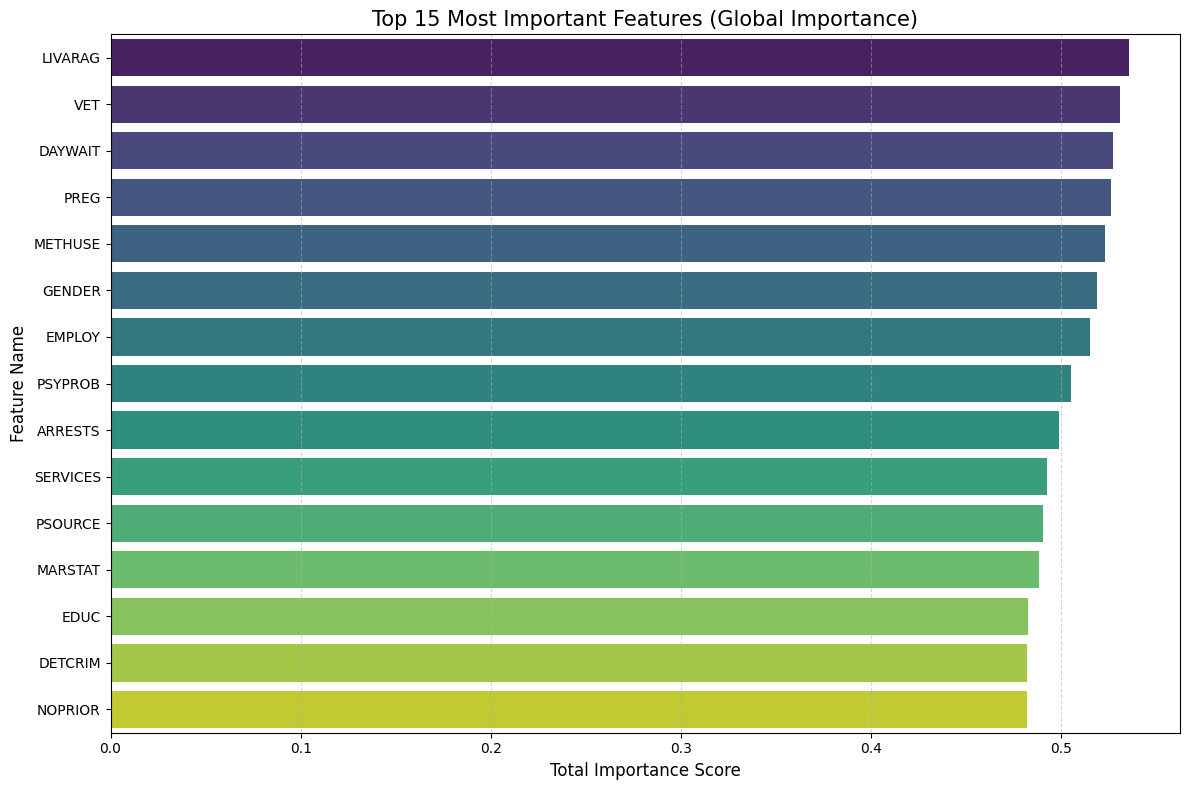

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. 노드 이름 매핑 정보 가져오기
# ---------------------------------------------------------
# load_trained_model에서 반환받은 pickle_data를 사용합니다.
# 구조: [train, val, test, col_info]
# col_info 구조: (col_list, col_dim)

col_info = pickle_data[3]
node_names_list = col_info[0] # 실제 컬럼명(노드명) 리스트

# 인덱스 -> 이름 매핑 딕셔너리 생성
node_map = {i: name for i, name in enumerate(node_names_list)}

print(f"✅ 노드 이름 매핑 완료! (총 {len(node_names_list)}개 노드)")
print(f"예시: Node 0 -> {node_names_list[0]}, Node 1 -> {node_names_list[1]}")

# ---------------------------------------------------------
# 2. 결과 데이터프레임에 이름 추가
# ---------------------------------------------------------
if global_results_df is not None:
    # (Source, Target) 별로 중요도 평균 계산
    summary_df = global_results_df.groupby(['Source Node', 'Target Node']).agg(
        Avg_Importance=('Importance', 'mean'),
        Count=('Importance', 'count')
    ).reset_index()

    # 🚨 [핵심] 노드 인덱스를 이름으로 변환하여 새 컬럼 추가
    summary_df['Source Name'] = summary_df['Source Node'].map(node_map)
    summary_df['Target Name'] = summary_df['Target Node'].map(node_map)

    # 중요도 기준 내림차순 정렬
    summary_df = summary_df.sort_values(by='Avg_Importance', ascending=False).reset_index(drop=True)

    print("\n" + "="*60)
    print(f"📊 Global Top 20 Important Edges (Named)")
    print("="*60)
    # 보기 좋게 이름과 중요도만 출력
    print(summary_df[['Source Name', 'Target Name', 'Avg_Importance']].head(20))

    # ---------------------------------------------------------
    # 3. 노드별 전체 중요도 (이름 기반 집계)
    # ---------------------------------------------------------
    # Source Node 기준으로 그룹화
    node_importance = summary_df.groupby(['Source Node', 'Source Name'])['Avg_Importance'].sum().reset_index()
    node_importance = node_importance.sort_values(by='Avg_Importance', ascending=False).reset_index(drop=True)

    print("\n" + "="*60)
    print("🌟 Global Top 15 Most Influential Features (Nodes)")
    print("="*60)
    print(node_importance[['Source Name', 'Avg_Importance']].head(15))

    # ---------------------------------------------------------
    # 4. 시각화 (이름으로 출력)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 8))
    
    # 상위 15개만 시각화
    top_nodes_df = node_importance.head(15)
    
    sns.barplot(
        x='Avg_Importance', 
        y='Source Name', # Y축에 이름을 표시
        data=top_nodes_df, 
        palette='viridis'
    )
    
    plt.title(f'Top 15 Most Important Features (Global Importance)', fontsize=15)
    plt.xlabel('Total Importance Score', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("❌ global_results_df가 없습니다. 분석 코드를 먼저 실행해주세요.")

In [44]:
summary_df

,Source Node,Target Node,Avg_Importance,Count,Source Name,Target Name
0,14,0,0.535678,1000,LIVARAG,STFIPS
1,13,0,0.530858,1000,VET,STFIPS
2,15,0,0.527470,1000,DAYWAIT,STFIPS
3,11,0,0.526000,1000,PREG,STFIPS
4,9,0,0.522881,1000,METHUSE,STFIPS
...,...,...,...,...,...,...
506,25,0,0.000000,1000,ROUTE1,STFIPS
507,24,6,0.000000,1000,SUB3,NOPRIOR
508,24,5,0.000000,1000,SUB3,PSOURCE
509,24,4,0.000000,1000,SUB3,DETCRIM


🔄 노드 양방향(Source + Target) 중요도 통합 분석 시작...
✅ 분석 완료! (총 60개 노드 집계됨)

🏆 Top 20 Most Important Nodes (Bidirectional Accumulation)
          Out_Importance (Source)  In_Importance (Target)  Total_Importance
STFIPS                   0.000000             7598.330078       7598.330078
LIVARAG                535.678101                0.000000        535.678101
VET                    530.858093                0.000000        530.858093
DAYWAIT                527.470459                0.000000        527.470459
PREG                   526.000000                0.000000        526.000000
METHUSE                522.880737                0.000000        522.880737
GENDER                 518.645813                0.000000        518.645813
EMPLOY                 514.976257                0.000000        514.976257
PSYPROB                505.136719                0.000000        505.136719
ARRESTS                498.869263                0.000000        498.869263
SERVICES               492.590424     

<Figure size 1400x800 with 0 Axes>

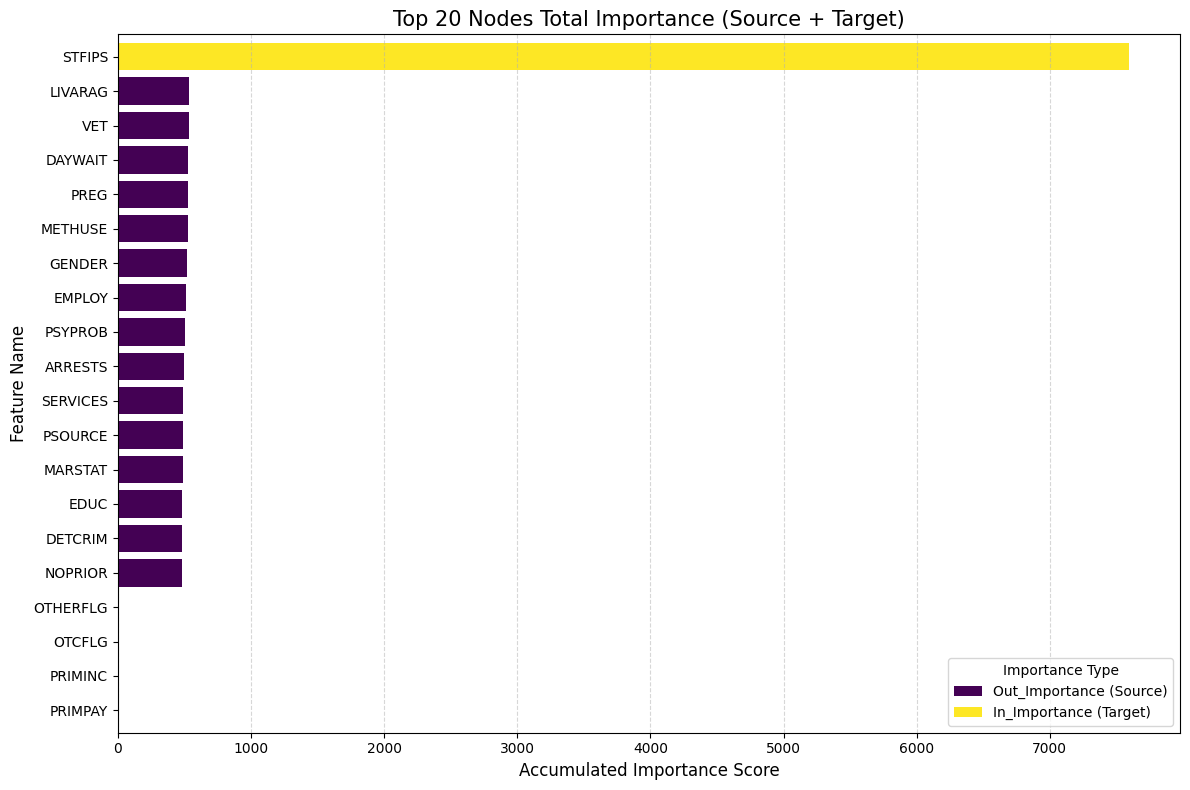

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_bidirectional_node_importance(global_results_df, pickle_data):
    print("🔄 노드 양방향(Source + Target) 중요도 통합 분석 시작...")
    
    # 1. 노드 이름 매핑 준비
    col_info = pickle_data[3]
    node_names_list = col_info[0]
    node_map = {i: name for i, name in enumerate(node_names_list)}
    
    # 2. 이름 매핑 (아직 안 되어 있다면)
    if 'Source Name' not in global_results_df.columns:
        global_results_df['Source Name'] = global_results_df['Source Node'].map(node_map)
        global_results_df['Target Name'] = global_results_df['Target Node'].map(node_map)
    
    # ---------------------------------------------------------
    # 3. 중요도 집계 (누적합)
    # ---------------------------------------------------------
    
    # (1) Source로서의 중요도 (Out-degree importance) -> "영향력"
    source_agg = global_results_df.groupby('Source Name')['Importance'].sum()
    
    # (2) Target로서의 중요도 (In-degree importance) -> "허브/수집력"
    target_agg = global_results_df.groupby('Target Name')['Importance'].sum()
    
    # (3) 데이터프레임으로 합치기 (Outer Join)
    # 어떤 노드는 Source로만, 어떤 노드는 Target으로만 등장할 수 있으므로 fillna(0) 필수
    total_node_df = pd.DataFrame({
        'Out_Importance (Source)': source_agg,
        'In_Importance (Target)': target_agg
    }).fillna(0)
    
    # (4) 총합 계산
    total_node_df['Total_Importance'] = total_node_df['Out_Importance (Source)'] + total_node_df['In_Importance (Target)']
    
    # 4. 정렬 (Total 기준 내림차순)
    total_node_df = total_node_df.sort_values(by='Total_Importance', ascending=False)
    
    print(f"✅ 분석 완료! (총 {len(total_node_df)}개 노드 집계됨)")
    
    return total_node_df

# --- 실행 ---
bidirectional_importance_df = analyze_bidirectional_node_importance(global_results_df, pickle_data)

# --- 결과 출력 ---
print("\n" + "="*60)
print("🏆 Top 20 Most Important Nodes (Bidirectional Accumulation)")
print("="*60)
print(bidirectional_importance_df.head(20))

# --- 시각화 (Stacked Bar Chart) ---
# Total 순위 상위 20개만 추출
top_20_nodes = bidirectional_importance_df.head(20)

# 시각화를 위해 데이터 재구조화 (Wide -> Long)
top_20_long = top_20_nodes[['Out_Importance (Source)', 'In_Importance (Target)']].reset_index()
top_20_long = top_20_long.melt(id_vars='index', var_name='Type', value_name='Importance')
top_20_long.rename(columns={'index': 'Node Name'}, inplace=True)

plt.figure(figsize=(14, 8))

# Stacked Bar Chart 느낌을 내기 위한 Plot
# (Seaborn으로 Stacked Bar는 조금 복잡하므로 Pandas Plot 활용이 더 깔끔합니다)
ax = top_20_nodes[['Out_Importance (Source)', 'In_Importance (Target)']].plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 8), 
    colormap='viridis',
    width=0.8
)

plt.title('Top 20 Nodes Total Importance (Source + Target)', fontsize=15)
plt.xlabel('Accumulated Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.legend(title='Importance Type', loc='lower right')
plt.gca().invert_yaxis() # 상위권이 위로 오게
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [47]:
import torch
from collections import Counter

def check_graph_topology(edge_index, pickle_data):
    print("🕸️ 그래프 연결 구조(Topology) 진단")
    
    # 노드 이름 매핑
    col_info = pickle_data[3]
    node_names = col_info[0]
    node_map = {i: name for i, name in enumerate(node_names)}
    
    # Edge Index 분리
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    
    # 1. 누가 가장 많이 타겟(도착지)이 되었는가? (In-Degree)
    dst_counts = Counter(dst)
    print("\n📉 Top 5 Nodes with Highest In-Degree (Information Receivers):")
    for idx, count in dst_counts.most_common(5):
        print(f"  - {node_map.get(idx, idx)}: {count} edges incoming")
        
    # 2. 누가 가장 많이 소스(출발지)가 되었는가? (Out-Degree)
    src_counts = Counter(src)
    print("\n📈 Top 5 Nodes with Highest Out-Degree (Information Senders):")
    for idx, count in src_counts.most_common(5):
        print(f"  - {node_map.get(idx, idx)}: {count} edges outgoing")

    # 3. STFIPS 확인
    stfips_indices = [k for k, v in node_map.items() if 'STFIPS' in v]
    if stfips_indices:
        st_idx = stfips_indices[0]
        print(f"\n🚨 'STFIPS' (Node {st_idx}) 연결 상태:")
        print(f"  - 들어오는 엣지 수 (In): {dst_counts[st_idx]}")
        print(f"  - 나가는 엣지 수 (Out): {src_counts[st_idx]}")

# --- 실행 ---
check_graph_topology(template_edge_index, pickle_data)

🕸️ 그래프 연결 구조(Topology) 진단

📉 Top 5 Nodes with Highest In-Degree (Information Receivers):
  - EDUC: 72 edges incoming
  - MARSTAT: 72 edges incoming
  - SERVICES: 72 edges incoming
  - DETCRIM: 72 edges incoming
  - PSOURCE: 72 edges incoming

📈 Top 5 Nodes with Highest Out-Degree (Information Senders):
  - STFIPS: 7 edges outgoing
  - EDUC: 7 edges outgoing
  - MARSTAT: 7 edges outgoing
  - SERVICES: 7 edges outgoing
  - DETCRIM: 7 edges outgoing

🚨 'STFIPS' (Node 0) 연결 상태:
  - 들어오는 엣지 수 (In): 72
  - 나가는 엣지 수 (Out): 7


In [42]:
from utils.processing_utils import get_col_info, get_ad_dis_col
import pandas as pd

df_path = os.path.join(CUR_DIR, 'data', 'missing_corrected.csv')
df = pd.read_csv(df_path)
ad_col_index, dis_col_index = get_ad_dis_col(df)


n = node_importance.copy()
ad_col_index


['STFIPS',
 'EDUC',
 'MARSTAT',
 'SERVICES',
 'DETCRIM',
 'PSOURCE',
 'NOPRIOR',
 'ARRESTS',
 'EMPLOY',
 'METHUSE',
 'PSYPROB',
 'PREG',
 'GENDER',
 'VET',
 'LIVARAG',
 'DAYWAIT',
 'DSMCRIT',
 'AGE',
 'RACE',
 'ETHNIC',
 'DETNLF',
 'PRIMINC',
 'SUB1',
 'SUB2',
 'SUB3',
 'ROUTE1',
 'ROUTE2',
 'ROUTE3',
 'FREQ1',
 'FREQ2',
 'FREQ3',
 'FRSTUSE1',
 'FRSTUSE2',
 'FRSTUSE3',
 'HLTHINS',
 'PRIMPAY',
 'FREQ_ATND_SELF_HELP',
 'ALCFLG',
 'COKEFLG',
 'MARFLG',
 'HERFLG',
 'METHFLG',
 'OPSYNFLG',
 'PCPFLG',
 'HALLFLG',
 'MTHAMFLG',
 'AMPHFLG',
 'STIMFLG',
 'BENZFLG',
 'TRNQFLG',
 'BARBFLG',
 'SEDHPFLG',
 'INHFLG',
 'OTCFLG',
 'OTHERFLG',
 'DIVISION',
 'REGION',
 'IDU',
 'ALCDRUG',
 'CBSA2020']

In [41]:
len(set(ad_col_index).union(set(dis_col_index)))


72

🔍 [Test Dataset] 전수 조사 시작...


Scanning Batches: 100%|██████████| 13071/13071 [00:00<00:00, 56317.22it/s]
/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_70740/3577361461.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(length_counts.keys()), y=list(length_counts.values()), palette='viridis')



📊 [Test Dataset] 길이 분포 요약
총 샘플 개수: 209121
발견된 길이 종류: 37개
----------------------------------------
Length     | Count      | Ratio(%)  
----------------------------------------
0          | 33980      | 16.25%
1          | 8739       | 4.18%
2          | 7547       | 3.61%
3          | 6726       | 3.22%
4          | 6829       | 3.27%
5          | 4779       | 2.29%
6          | 4386       | 2.10%
7          | 3278       | 1.57%
8          | 2261       | 1.08%
9          | 1866       | 0.89%
10         | 1518       | 0.73%
11         | 1368       | 0.65%
12         | 1820       | 0.87%
13         | 2229       | 1.07%
14         | 2021       | 0.97%
15         | 1345       | 0.64%
16         | 1201       | 0.57%
17         | 1162       | 0.56%
18         | 1177       | 0.56%
19         | 1399       | 0.67%
20         | 2193       | 1.05%
21         | 1732       | 0.83%
22         | 1349       | 0.65%
23         | 1227       | 0.59%
24         | 1129       | 0.54%
25         | 1184     

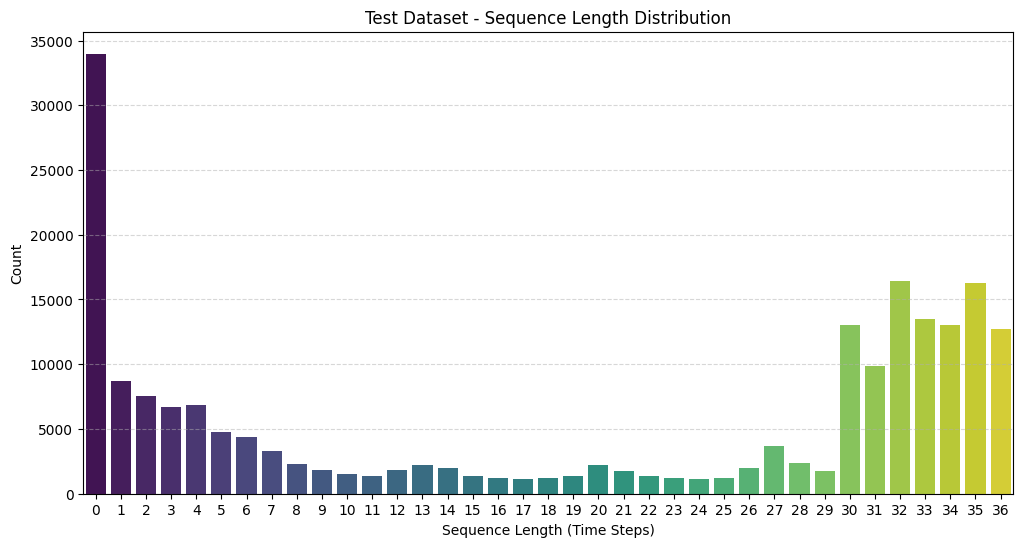

In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def cross_check_dataset_lengths(dataset, name="Test Dataset"):
    """
    데이터셋 내의 모든 배치, 모든 개별 샘플의 마스크를 확인하여
    실제 유효 길이(Length) 분포를 출력합니다.
    """
    print(f"🔍 [{name}] 전수 조사 시작...")
    
    all_lengths = []
    
    # 1. 모든 배치 순회
    for batch_idx, signal in enumerate(tqdm(dataset, desc="Scanning Batches")):
        try:
            # signal.mask 구조: List[np.array shape=(Batch_Size,)] (길이: 37)
            # -> Time-Major (시간 축이 리스트)
            
            mask_list = signal.mask
            
            # 마스크가 없는 경우 체크
            if not mask_list or mask_list[0] is None:
                print(f"⚠️ Warning: Batch {batch_idx} has no mask!")
                continue
                
            # (Time_Steps, Batch_Size) 형태로 스택
            # 예: (37, 32)
            mask_stack = np.stack(mask_list)
            
            # (Batch_Size, Time_Steps) 형태로 전치 -> 개별 샘플(환자) 기준
            # 예: (32, 37)
            mask_per_sample = mask_stack.T
            
            # 각 샘플별 길이 계산 (1의 개수 = 유효 길이)
            # axis=1 (시간 축)을 따라 합계
            lengths = mask_per_sample.sum(axis=1)
            
            # 결과 리스트에 추가
            all_lengths.extend(lengths.tolist())
            
        except Exception as e:
            print(f"❌ Error at Batch {batch_idx}: {e}")
            continue
            
    # 2. 통계 집계
    total_samples = len(all_lengths)
    length_counts = Counter(all_lengths)
    sorted_lengths = sorted(length_counts.keys())
    
    print(f"\n📊 [{name}] 길이 분포 요약")
    print(f"총 샘플 개수: {total_samples}")
    print(f"발견된 길이 종류: {len(sorted_lengths)}개")
    print("-" * 40)
    print(f"{'Length':<10} | {'Count':<10} | {'Ratio(%)':<10}")
    print("-" * 40)
    
    for length in sorted_lengths:
        count = length_counts[length]
        ratio = (count / total_samples) * 100
        print(f"{length:<10} | {count:<10} | {ratio:.2f}%")
        
    print("-" * 40)
    
    # 3. 시각화
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(length_counts.keys()), y=list(length_counts.values()), palette='viridis')
    plt.title(f'{name} - Sequence Length Distribution')
    plt.xlabel('Sequence Length (Time Steps)')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
    
    return length_counts

# --- 실행 ---
# 이미 로드된 test_dataset 변수가 있다고 가정합니다.
# 만약 없다면 Cell 2를 먼저 실행하세요.

if 'test_dataset' in locals():
    length_stats = cross_check_dataset_lengths(test_dataset, name="Test Dataset")
else:
    print("🚨 test_dataset 변수가 없습니다. 데이터 로드 셀을 먼저 실행해 주세요.")

In [45]:
def cross_check_dimensions(model, pickle_data, template_edge_index, global_results_df):
    print("🔍 [Dimension Cross-Check Report]")
    print("=" * 50)

    # 1. 피클에 저장된 '노드 이름 리스트' 확인
    # pickle_data[3] = (col_list, col_dim)
    col_list = pickle_data[3][0]
    num_names = len(col_list)
    print(f"1. 피클 파일에 저장된 노드 이름 개수 (col_list): {num_names}개")
    if num_names != 60:
        print(f"   ⚠️ 예상(60개)과 다릅니다! -> DataBundle 생성 시 72개 컬럼이 ad 리스트에 들어갔습니다.")
    
    # 2. 실제 그래프(Edge Index)에 등장하는 노드 번호 확인
    # 템플릿 엣지 인덱스에서 가장 큰 노드 번호 찾기
    max_node_idx = template_edge_index.max().item()
    print(f"2. 엣지 인덱스에 등장하는 최대 노드 번호: {max_node_idx} (총 {max_node_idx + 1}개 노드 추정)")
    
    # 3. 모델의 임베딩 레이어 개수 확인
    # A3TGCNCat2 -> entitiy_embedding -> embs (ModuleList)
    # 모델이 학습할 때 몇 개의 컬럼(노드)에 대해 임베딩을 만들었는지 확인
    try:
        num_embeddings = len(model.entitiy_embedding.embs)
        print(f"3. 모델 내부 엔티티 임베딩 레이어 개수: {num_embeddings}개")
    except:
        print("3. 모델 임베딩 레이어 개수 확인 불가 (구조 상이)")

    # 4. 분석 결과 데이터프레임의 유니크 노드 수 확인
    if global_results_df is not None:
        unique_source = global_results_df['Source Node'].nunique()
        unique_target = global_results_df['Target Node'].nunique()
        print(f"4. 중요도 분석 결과에 등장한 유니크 Source 노드 수: {unique_source}개")
        
        # 72개인지 확인
        if unique_source == 72 or num_names == 72:
            print("\n🚨 [진단 결과]: 데이터 전처리(DataBundle) 단계에서 실제로 72개의 노드가 생성되었습니다.")
            print("   -> get_ad_dis_col 함수가 60개가 아닌 72개의 컬럼을 'Admission' 컬럼으로 판단했습니다.")
            print("   -> 실제 저장된 이름 리스트의 일부를 출력해 확인해 보세요.")
            print(f"   -> 예시: {col_list[:5]} ...")
    
    print("=" * 50)

# --- 실행 ---
cross_check_dimensions(model, pickle_data, template_edge_index, global_results_df)

🔍 [Dimension Cross-Check Report]
1. 피클 파일에 저장된 노드 이름 개수 (col_list): 60개
2. 엣지 인덱스에 등장하는 최대 노드 번호: 72 (총 73개 노드 추정)
3. 모델 내부 엔티티 임베딩 레이어 개수: 60개
4. 중요도 분석 결과에 등장한 유니크 Source 노드 수: 73개


In [ ]:
import random
import pandas as pd
from tqdm import tqdm
import torch
import numpy as np

# 🚨 [중요] 길이 0인 샘플은 분석에서 제외합니다.
MIN_SEQ_LEN = 1 

def analyze_importance_by_individual_sample(dataset, model, explainer, max_samples_per_group=20):
    """
    배치(Batch) 내부를 뜯어서 개별 샘플 단위로 길이를 측정하고,
    길이별로 그룹화하여 중요도를 분석합니다. (길이 0 제외)
    """
    
    # -------------------------------------------------------
    # 1. 전수 조사: (Batch_Index, Sample_Index) 별로 길이 측정
    # -------------------------------------------------------
    length_groups = {}
    
    print("🕵️ 배치 내부 개별 샘플 전수 조사 및 그룹화 중...")
    
    for batch_idx, signal in enumerate(tqdm(dataset, desc="Scanning Batches")):
        try:
            mask_list = signal.mask # List[np.array] (Time_Major)
            if not mask_list or mask_list[0] is None:
                continue
            
            # (Time_Steps, Batch_Size) -> (37, 32)
            mask_stack = np.stack(mask_list) 
            
            # (Batch_Size, Time_Steps) -> (32, 37) : 환자 기준
            mask_per_sample = mask_stack.T 
            
            # 각 샘플별 유효 길이 계산 (1의 합계)
            lengths = mask_per_sample.sum(axis=1)
            
            # 그룹에 등록
            for sample_in_batch_idx, length in enumerate(lengths):
                # 🚨 길이 0인 데이터는 설명 불가능하므로 패스
                if length < MIN_SEQ_LEN: 
                    continue
                
                if length not in length_groups:
                    length_groups[length] = []
                
                # (배치 번호, 배치 내 순서) 저장
                length_groups[length].append((batch_idx, sample_in_batch_idx))
                
        except Exception as e:
            continue

    sorted_lengths = sorted(length_groups.keys())
    print(f"\n🔍 분석 대상 길이 그룹 (0 제외): {sorted_lengths}")
    
    aggregated_results = []
    
    # -------------------------------------------------------
    # 2. 각 길이 그룹별 분석 실행
    # -------------------------------------------------------
    for seq_len in sorted_lengths:
        pairs = length_groups[seq_len]
        
        # 랜덤 샘플링 (너무 많으면 자름)
        if len(pairs) > max_samples_per_group:
            target_pairs = random.sample(pairs, max_samples_per_group)
        else:
            target_pairs = pairs
            
        print(f"\n🚀 [Length {seq_len}] 그룹 분석 시작 (Random {len(target_pairs)} samples)...")
        
        for (batch_idx, sample_idx_in_batch) in tqdm(target_pairs, desc=f"Analyzing Len {seq_len}"):
            try:
                # 해당 배치를 가져옴
                signal_iter = dataset[batch_idx]
                signal_list = list(signal_iter)
                batch_list = [b.to(DEVICE) for b in signal_list]
                
                # --- (A) 시간적 중요도 ---
                current_edge_index = batch_list[0].edge_index
                temporal_weights = explainer.get_temporal_importance(batch_list, current_edge_index)
                if temporal_weights.dim() > 1:
                    temporal_weights = temporal_weights[0]
                
                best_time_idx = torch.argmax(temporal_weights).item()
                
                # --- (B) 공간적 중요도 ---
                target_batch = batch_list[best_time_idx]
                
                with torch.no_grad():
                    x_emb_raw = model.entitiy_embedding(target_batch)
                    target_layer = model.a3tgcn_layers[0]._base_tgcn.conv_h
                    expected_in_channels = target_layer.in_channels
                    x_emb = x_emb_raw.reshape(-1, expected_in_channels)
                
                # 🚨 해당 샘플(환자)에 해당하는 노드만 찾아서 설명
                batch_vec = target_batch.batch # [0,0, ... 1,1, ...]
                node_indices = (batch_vec == sample_idx_in_batch).nonzero(as_tuple=True)[0]
                
                if len(node_indices) == 0:
                    continue
                
                # 해당 그래프의 첫 번째 노드(Node 0)를 대표로 설명
                target_node_global_idx = node_indices[0].item()
                
                # GNNExplainer 실행
                edge_mask, _ = explainer.explain_spatial_step(
                    x_emb, target_batch.edge_index, node_idx=target_node_global_idx
                )
                
                mask_np = edge_mask.detach().cpu().numpy()
                edges_np = target_batch.edge_index.cpu().numpy()
                
                # 🚨 중요: 결과 필터링 (내 그래프의 엣지만 남기기)
                min_node = node_indices.min().item()
                max_node = node_indices.max().item()
                
                # Source가 내 그래프 범위 안에 있는 엣지만 선택
                relevant_edge_mask = (edges_np[0] >= min_node) & (edges_np[0] <= max_node)
                
                # 인덱스 0~59로 정규화
                local_source = edges_np[0][relevant_edge_mask] - min_node
                local_target = edges_np[1][relevant_edge_mask] - min_node
                local_importance = mask_np[relevant_edge_mask]
                
                sample_df = pd.DataFrame({
                    'Source Node': local_source,
                    'Target Node': local_target,
                    'Importance': local_importance,
                    'Batch_ID': batch_idx,
                    'Sample_ID': sample_idx_in_batch,
                    'Seq_Len': seq_len
                })
                aggregated_results.append(sample_df)
                
            except Exception as e:
                # print(f"⚠️ Error: {e}") 
                continue
    
    if not aggregated_results:
        return None

    total_df = pd.concat(aggregated_results, ignore_index=True)
    return total_df

# --- 실행 ---
# max_samples_per_group=20 정도로 설정하여 실행해 보세요.
# (시간 길이에 따라 약 10~20분 정도 소요될 수 있습니다)
df_by_individual_length = analyze_importance_by_individual_sample(
    test_dataset, 
    model, 
    explainer, 
    max_samples_per_group=20
)

print("\n✅ 개별 샘플 길이 기반 분석이 완료되었습니다.")

🕵️ 배치 내부 개별 샘플 전수 조사 중...


Scanning Batches: 100%|██████████| 13071/13071 [00:00<00:00, 63411.72it/s]



🔍 발견된 개별 샘플 길이 그룹: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]

🚀 [Individual Length 1] 그룹 분석 시작 (Random 10 samples)...


Analyzing Len 1: 100%|██████████| 10/10 [00:06<00:00,  1.59it/s]



🚀 [Individual Length 2] 그룹 분석 시작 (Random 10 samples)...


Analyzing Len 2:  50%|█████     | 5/10 [00:03<00:03,  1.54it/s]


KeyboardInterrupt: 

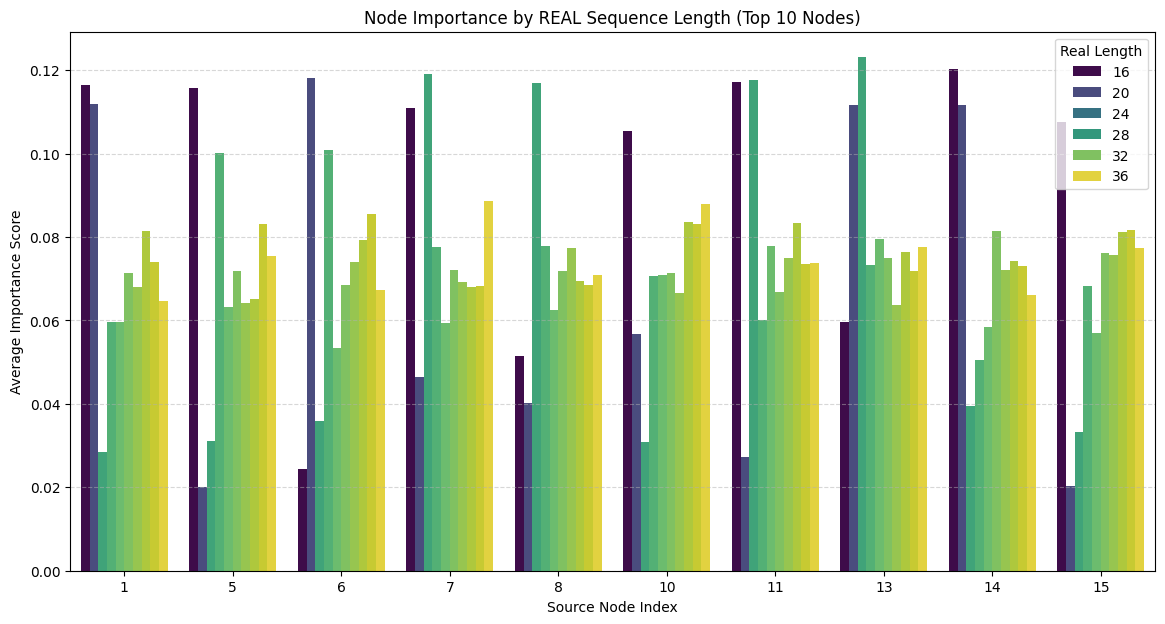


LENGTH 16: Top 3 Important Nodes
    Seq_Len  Source Node  Avg_Importance
14       16           14        0.120202
11       16           11        0.117063
1        16            1        0.116393

LENGTH 20: Top 3 Important Nodes
    Seq_Len  Source Node  Avg_Importance
79       20            6        0.118122
76       20            3        0.112576
74       20            1        0.111897

LENGTH 29: Top 3 Important Nodes
     Seq_Len  Source Node  Avg_Importance
159       29           13        0.123071
150       29            4        0.119477
153       29            7        0.119166

LENGTH 30: Top 3 Important Nodes
     Seq_Len  Source Node  Avg_Importance
225       30            6        0.100769
224       30            5        0.100053
227       30            8        0.077795

LENGTH 31: Top 3 Important Nodes
     Seq_Len  Source Node  Avg_Importance
305       31           13        0.079565
303       31           11        0.077971
296       31            4        0.07320

In [80]:
if df_by_real_length is not None:
    import seaborn as sns
    import matplotlib.pyplot as plt

    # 1. 데이터프레임 요약 (길이별, 노드별 중요도 평균)
    summary_real = df_by_real_length.groupby(['Seq_Len', 'Source Node']).agg(
        Avg_Importance=('Importance', 'mean')
    ).reset_index()
    
    # 2. 전체적으로 가장 중요한 상위 10개 노드 선정 (시각화 대상 선정용)
    top_nodes = summary_real.groupby('Source Node')['Avg_Importance'].mean().sort_values(ascending=False).head(10).index
    
    # 3. 상위 10개 노드에 대해서만 필터링
    filtered_df = summary_real[summary_real['Source Node'].isin(top_nodes)]
    
    # 4. 시각화
    plt.figure(figsize=(14, 7))
    
    # 막대 그래프로 길이별 변화 비교
    sns.barplot(
        data=filtered_df,
        x='Source Node', 
        y='Avg_Importance', 
        hue='Seq_Len', # 색깔로 길이 구분
        palette='viridis'
    )
    
    plt.title('Node Importance by REAL Sequence Length (Top 10 Nodes)')
    plt.xlabel('Source Node Index')
    plt.ylabel('Average Importance Score')
    plt.legend(title='Real Length')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
    
    # 5. 텍스트 요약 출력 (길이별 Top 3 노드)
    unique_lens = sorted(df_by_real_length['Seq_Len'].unique())
    for l in unique_lens:
        print(f"\nLENGTH {l}: Top 3 Important Nodes")
        sub = summary_real[summary_real['Seq_Len'] == l].sort_values('Avg_Importance', ascending=False).head(3)
        print(sub)

In [51]:
train_dataset, val_dataset, test_dataset

([<torch_geometric_temporal.signal.static_graph_temporal_signal_batch.StaticGraphTemporalSignalBatch at 0x3452959d0>,
  ...],
  ...],
  ...])

In [63]:
test_dataset[3].t

0

In [72]:
test_dataset[0].mask

[array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]),
 array([1, 0, 